# MongoDB + Python 실습 (Windows)
- Python(pymongo) 을 이용

In [1]:
! pip install pymongo

In [2]:
## 라이브러리 잘 읽어오는지 확인
from pymongo import MongoClient

In [4]:
# MongoDB 로컬 서버 연결
## mongodb 접속 포트 : 27017
client = MongoClient("mongodb://localhost:27017/")

## MongoDB 데이터베이스 생성
db = client["testdb"]

## 컬렉션 생성 (>>RDBMS table)
collection = db["students"]

## 데이터 삽입
collection.insert_one({"name": "홍길동", "age": 23, "major": "컴퓨터공학"})

InsertOneResult(ObjectId('6a1ce2266896e6de4d974f79'), acknowledged=True)

In [5]:
## 데이터 조회
for doc in collection.find():
    print(doc)

{'_id': ObjectId('6a1ce2266896e6de4d974f79'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}


# 기본 CRUD 실습
- CRUD는 Create, Read, Update, Delete의 약자

In [6]:
# DB 생성 및 연결
## MongoDB 로컬 서버 연결
client = MongoClient("mongodb://localhost:27017/")
## MongoDB 데이터베이스 생성
db = client["testdb"]
## 컬렉션 생성 (>>RDBMS table)
collection = db["students"]

## Create
collection.insert_many([
    {"name": "김철수", "age": 21, "major": "물리학"},
    {"name": "박민수", "age": 29, "major": "영문학"},
    {"name": "김소희", "age": 31, "major": "전자공학"},
    {"name": "홍길동", "age": 36, "major": "영문학"},
    {"name": "여흥철", "age": 28, "major": "체육학"},
    {"name": "이영희", "age": 22, "major": "수학"},
])

InsertManyResult([ObjectId('6a1ce9f46896e6de4d974f7b'), ObjectId('6a1ce9f46896e6de4d974f7c'), ObjectId('6a1ce9f46896e6de4d974f7d'), ObjectId('6a1ce9f46896e6de4d974f7e'), ObjectId('6a1ce9f46896e6de4d974f7f'), ObjectId('6a1ce9f46896e6de4d974f80')], acknowledged=True)

In [7]:
## Update
collection.update_one({"name":"김철수"}, {"$set": {"age":45}})

UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [8]:
## Delete
collection.delete_one({"name": "이영희"})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [9]:
collection.delete_one({"name": "김철수"})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [11]:
## Read (읽어서 분석해야 함/여러 데이터 한번에)
for student in collection.find():
    print(student)

client.close() # DB연결을 끊는다.

{'_id': ObjectId('6a1ce2266896e6de4d974f79'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a1ce9f46896e6de4d974f7c'), 'name': '박민수', 'age': 29, 'major': '영문학'}
{'_id': ObjectId('6a1ce9f46896e6de4d974f7d'), 'name': '김소희', 'age': 31, 'major': '전자공학'}
{'_id': ObjectId('6a1ce9f46896e6de4d974f7e'), 'name': '홍길동', 'age': 36, 'major': '영문학'}
{'_id': ObjectId('6a1ce9f46896e6de4d974f7f'), 'name': '여흥철', 'age': 28, 'major': '체육학'}


# csv 파일 읽어서 -> MongoDB 저장

In [12]:
import pandas as pd # 판다스 라이브러리로 csv 읽어오기 위함

## csv 파일 읽어오기
df = pd.read_csv('./data/Subjects.csv')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


In [13]:
## DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students_csv"]

## DataFrame을 딕셔너리 리스트로 변환 후 MongoDB에 저장 (DataFrame을 그대로 넣으면 안된다.)
collection.insert_many(df.to_dict("records")) # df(dataframe)를 딕셔너리로 변경 ex. [{},{},{}] 형태의 리스트로 변환
print("csv 데이터가 mongodb에 저장되었습니다.")

## Read
for students_csv in collection.find():
    print(students_csv)

client.close()

csv 데이터가 mongodb에 저장되었습니다.
{'_id': ObjectId('6a1ceec26896e6de4d974f82'), 'class': 1, 'name': 'aaa', 'kor': 67, 'eng': 87, 'math': 90, 'science': 98}
{'_id': ObjectId('6a1ceec26896e6de4d974f83'), 'class': 1, 'name': 'bbb', 'kor': 45, 'eng': 45, 'math': 56, 'science': 98}
{'_id': ObjectId('6a1ceec26896e6de4d974f84'), 'class': 1, 'name': 'ccc', 'kor': 95, 'eng': 59, 'math': 96, 'science': 88}
{'_id': ObjectId('6a1ceec26896e6de4d974f85'), 'class': 1, 'name': 'ddd', 'kor': 65, 'eng': 94, 'math': 89, 'science': 98}
{'_id': ObjectId('6a1ceec26896e6de4d974f86'), 'class': 1, 'name': 'eee', 'kor': 45, 'eng': 65, 'math': 78, 'science': 98}
{'_id': ObjectId('6a1ceec26896e6de4d974f87'), 'class': 1, 'name': 'fff', 'kor': 78, 'eng': 76, 'math': 98, 'science': 89}
{'_id': ObjectId('6a1ceec26896e6de4d974f88'), 'class': 2, 'name': 'ggg', 'kor': 87, 'eng': 67, 'math': 65, 'science': 56}
{'_id': ObjectId('6a1ceec26896e6de4d974f89'), 'class': 2, 'name': 'hhh', 'kor': 89, 'eng': 98, 'math': 78, 'science': 7

# 이미지 --> MongoDB에 저장


In [15]:
## 이미지를 바이트스트링으로 변환하기 위한 라이브러리 임포트
import base64
from io import BytesIO

In [17]:
## 이미지파일을 읽어와서 인코드
with open("./data/test-image.gif",  "rb") as img_file:
    encoded = base64.b64encode(img_file.read()).decode("utf-8")

## DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["images"]

## MongoDB 에 저장
collection.insert_one({"filename":"test-image", "data":encoded})

InsertOneResult(ObjectId('6a1cf1fb6896e6de4d974f8f'), acknowledged=True)

# MongoDB이미지 --> python 출력

In [ ]:
## 이미지 저장: 이미지 -> base64 -> 바이너리로 변환(encode) -> 저장
## 이미지 불러오기: base64 -> 바이너리 -> 이미지 객체로 변환(decode)하여 출력

MongoDB에서 이미지를 읽어왔습니다.


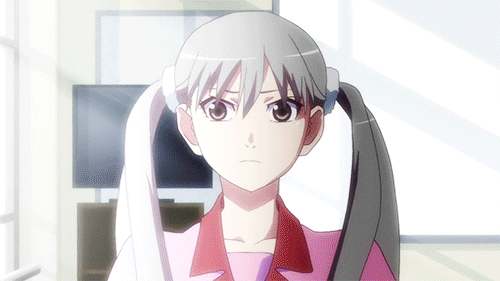

In [19]:
from PIL import Image

## MongoDB에서 이미지 데이터 가져오기
document = collection.find_one({"filename": "test-image"})
if document:
    img_data = document["data"]
    img_binary = base64.b64decode(img_data) # base64 바이너리로 변환
    img = Image.open(BytesIO(img_binary)) # 메모리에서 바로 이미지 객체 생성
    print("MongoDB에서 이미지를 읽어왔습니다.")
    display(img)
else:
    print("test-image 이미지를 찾을 수 없습니다.")

# 퀴즈1) MongoDB student_csv 콜렉션에 있는 데이터를 읽어와 막대 그래프를 출력하기
- 영어 점수만 뽑아와서 막대 그래프 출력

[87, 45, 59, 94, 65, 76, 67, 98, 78, 89, 45, 89]


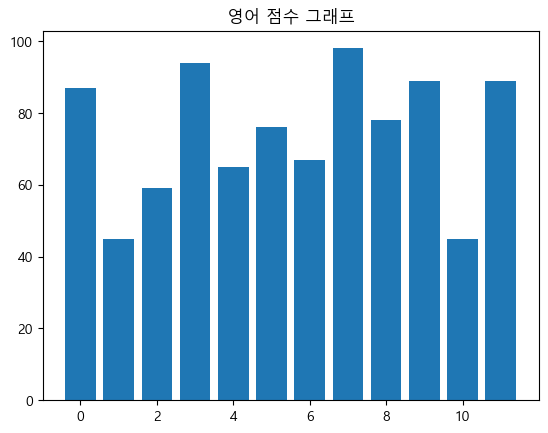

In [33]:
import matplotlib.pyplot as plt

collection = db["students_csv"]
engs = []

for students_csv in collection.find({}):
    eng = students_csv["eng"]
    engs.append(eng)
    # print(students_csv)

print(engs)

## plt.bar(x위치, 높이) / range(len(engs))는 x축 위치,
plt.bar(range(len(engs)), engs)

plt.title("영어 점수 그래프")
plt.rcParams['font.family'] = 'Malgun Gothic' # 맑은고딕
plt.rcParams['axes.unicode_minus'] = False
# x축: 이름, y축: 영어점수

plt.show()

In [ ]:
# ## 나의 풀이 -v2
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib import font_manager, rc
# from pymongo import MongoClient

# ## 한글 폰트 설정(Windows 기본: 맑은고딕(Malgun Gothic))
# # font_path = "C:/Windows/Fonts/malgun.ttf"
# # font_name = font_manager.FontProperties(fname=font_path).get_name()
# # rc('font', family=font_name)

# ## 음수 값 표시 문제 방지
# # plt.rcParams['axes.unicode_minus'] = False

# ## DB 연결
# # client = MongoClient("mongodb://localhost:27017/")
# # db = client["testdb"]
# # collection = db["students_csv"]

# ## MongoDB --> DataFrame
# data = pd.DataFrame(list(collection.find({}, {"_id": 0}))) # _id는 안가져옴

# selectedDatas = data[['name','eng']]

# names = []
# engs = []
# for idx, row in selectedDatas.iterrows():
#     name = row["name"]
#     eng = row["eng"]
#     print(f"name:{name}, eng:{eng}")
#     names.append(name)
#     engs.append(eng)

# print(names)
# print(engs)

# # 시각화 (x축: 이름, y축: 영어점수)
# plt.title("영어 점수 그래프(x=이름, y=영어점수)")

# ## plt.bar(x위치, 높이) / range(len(engs))는 x축 위치,
# plt.ylabel("y축: 영어점수")
# plt.bar(range(len(engs)), engs) # y축영여점수
# plt.xlabel("x축: 이름")
# plt.xticks(range(len(names)), names)

# plt.show()

# # DB 종료
# client.close()

In [ ]:
# 나이 분포 히스토그램, 전공별 학생 수 막대그래프, 전공별 나이 분포 박스플롯

  name  age  major
0  홍길동   23  컴퓨터공학
1  박민수   29    영문학
2  김소희   31   전자공학
3  홍길동   36    영문학
4  여흥철   28    체육학


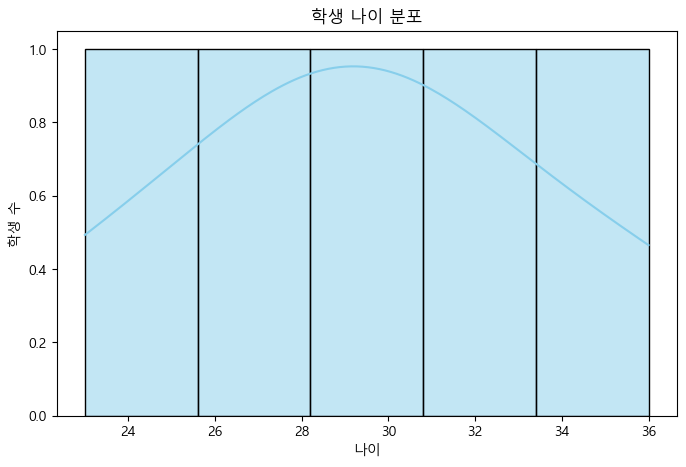

C:\Users\human3_02\AppData\Local\Temp\ipykernel_3800\3207930691.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="major", data=df, palette="pastel")


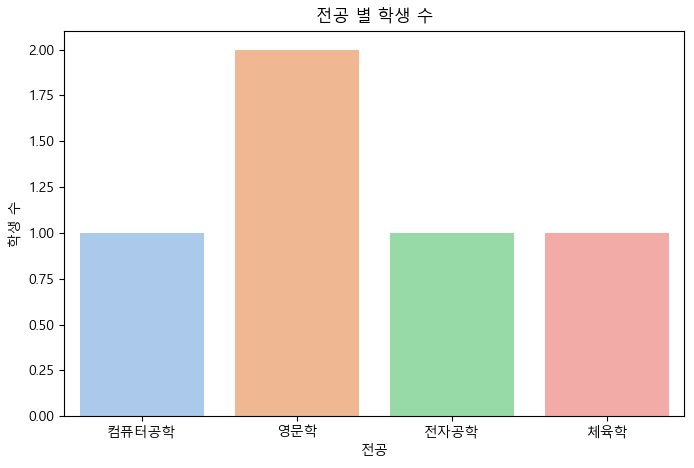

C:\Users\human3_02\AppData\Local\Temp\ipykernel_3800\3207930691.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="age", data=df, palette="Set2")


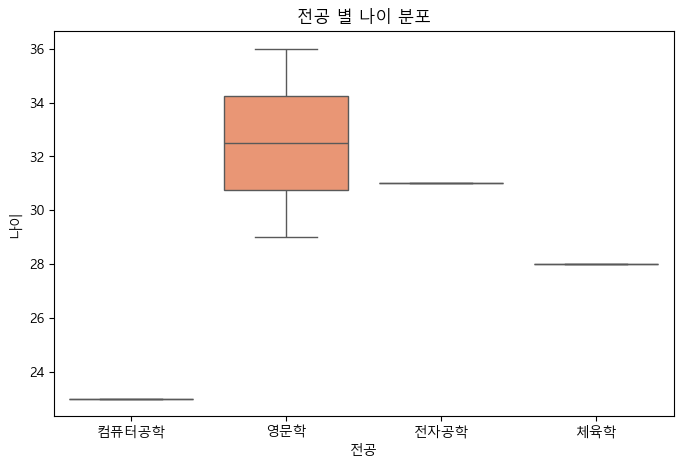

In [16]:
## 교수님 풀이
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from pymongo import MongoClient

# 한글 폰트 설정 (Windows 기준, Mac은 "AppleGothic")
rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

## DB 연결 및 데이터 불러오기
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students"]
# ## MongoDB --> DataFrame
# data = pd.DataFrame(list(collection.find({}, {"_id": 0}))) # _id는 안가져옴

cursor = collection.find({})
df = pd.DataFrame(list(cursor))
client.close()

## _id 컬럼 제거
if "_id" in df.columns:
    df = df.drop("_id", axis=1)

print(df)

## 나이 분포 히스토그램: 나중에 분포 비교하는것 굉장히 많이 사용 (언덕 두개 꼭대기 중심점 차이 비교분석)
plt.figure(figsize=(8,5))
sns.histplot(df.age, bins=5, kde=True, color="skyblue")
plt.title("학생 나이 분포")
plt.xlabel("나이")
plt.ylabel("학생 수")
plt.show()

## 전공별 학생 수 막대그래프
plt.figure(figsize=(8,5))
sns.countplot(x="major", data=df, palette="pastel")
plt.title("전공 별 학생 수")
plt.xlabel("전공")
plt.ylabel("학생 수")
plt.show()

## 전공별 나이 분포 박스플롯
plt.figure(figsize=(8,5))
sns.boxplot(x="major", y="age", data=df, palette="Set2")
plt.title("전공 별 나이 분포")
plt.xlabel("전공")
plt.ylabel("나이")
plt.show()

# DB 종료
client.close()

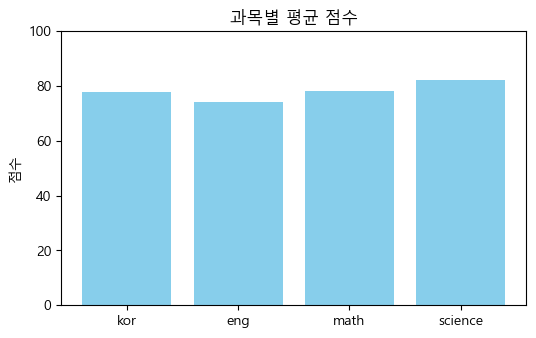

In [18]:
import tkinter as tk
from tkinter import ttk
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows용)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# MongoDB 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students_csv"]

# 데이터 불러오기
data = list(collection.find({}, {"_id": 0}))
df = pd.DataFrame(data)
client.close()

# Tkinter 메인 윈도우
root = tk.Tk()
root.title("학생 점수 대시보드")
root.geometry("900x700")

# === 제목 ===
title_label = tk.Label(root, text="학생 점수 대시보드", font=("Malgun Gothic", 18, "bold"))
title_label.pack(pady=10)

# === Treeview 테이블 ===
frame_table = tk.Frame(root)
frame_table.pack(pady=10)

columns = list(df.columns)
tree = ttk.Treeview(frame_table, columns=columns, show="headings", height=10)

# 컬럼 헤더 설정
for col in columns:
    tree.heading(col, text=col)
    tree.column(col, width=100, anchor="center")

# 데이터 삽입
for _, row in df.iterrows():
    tree.insert("", "end", values=list(row))
tree.pack()

# === Matplotlib 그래프 표시 ===
frame_graph = tk.Frame(root)
frame_graph.pack(pady=20)

# 과목별 평균 계산
mean_scores = df[["kor", "eng", "math", "science"]].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mean_scores.index, mean_scores.values, color="skyblue")
ax.set_title("과목별 평균 점수")
ax.set_ylabel("점수")
ax.set_ylim(0, 100)

# Tkinter에 matplotlib 그래프 추가
canvas = FigureCanvasTkAgg(fig, master=frame_graph)
canvas.draw()
canvas.get_tk_widget().pack()

# === 종료 버튼 ===
exit_button = tk.Button(root, text="닫기", command=root.destroy, font=("Malgun Gothic", 12))
exit_button.pack(pady=10)

# Tkinter 실행
root.mainloop()

In [19]:
# db 종료
client.close()